In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Connect to the Chinook database
engine = create_engine('sqlite:///Chinook_Sqlite.sqlite')

# Test the connection
conn = engine.connect()
print("Connected to Chinook database!")

Connected to Chinook database!


In [2]:
# See all tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql(query, conn)
print(tables)

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


In [3]:
# Question 1: Which country has the most customers?
query = """
SELECT Country, COUNT(*) as Total_Customers
FROM Customer
GROUP BY Country
ORDER BY Total_Customers DESC
LIMIT 10
"""
df1 = pd.read_sql(query, conn)
print(df1)

          Country  Total_Customers
0             USA               13
1          Canada                8
2          France                5
3          Brazil                5
4         Germany                4
5  United Kingdom                3
6        Portugal                2
7           India                2
8  Czech Republic                2
9          Sweden                1


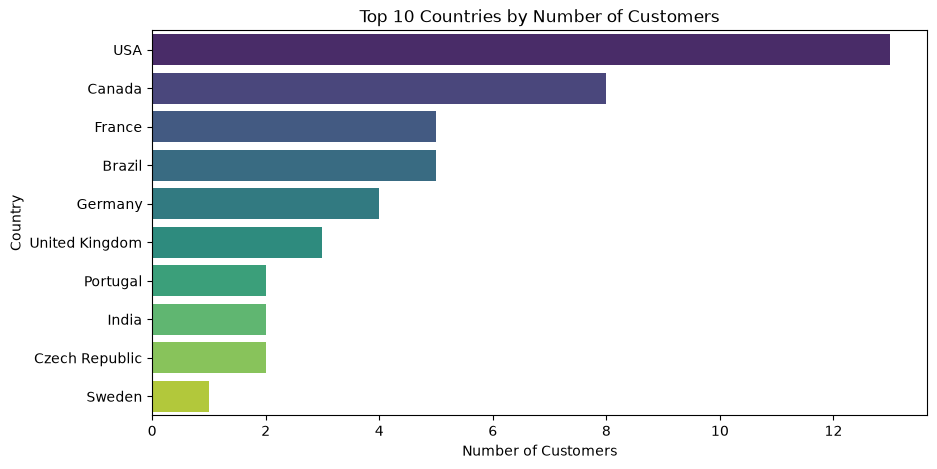

In [4]:
# Visualize customers by country
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x='Total_Customers', y='Country', data=df1, hue='Country', palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.show()

In [5]:
# Question 2: Which country generates the most revenue?
query = """
SELECT c.Country, ROUND(SUM(i.Total), 2) as Total_Revenue
FROM Invoice i
JOIN Customer c ON i.CustomerId = c.CustomerId
GROUP BY c.Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""
df2 = pd.read_sql(query, conn)
print(df2)

          Country  Total_Revenue
0             USA         523.06
1          Canada         303.96
2          France         195.10
3          Brazil         190.10
4         Germany         156.48
5  United Kingdom         112.86
6  Czech Republic          90.24
7        Portugal          77.24
8           India          75.26
9           Chile          46.62


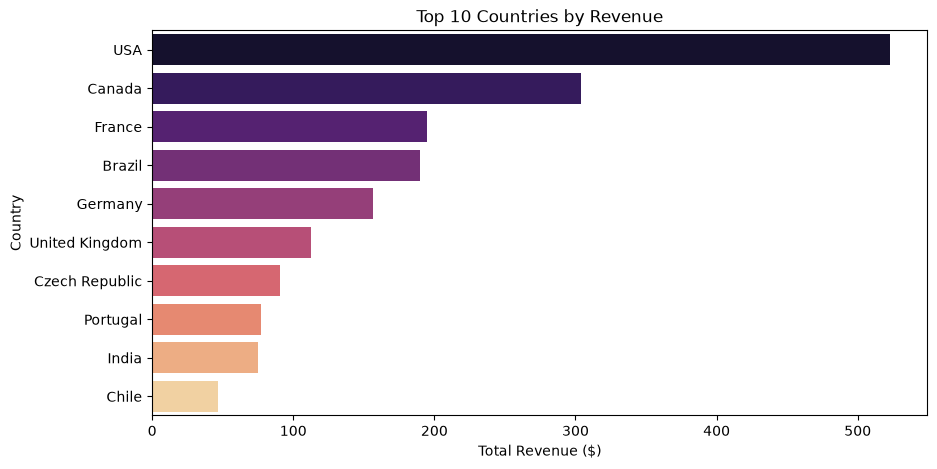

In [6]:
# Visualize revenue by country
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Revenue', y='Country', data=df2, hue='Country', palette='magma', legend=False)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Country')
plt.show()

In [7]:
# Question 3: Who are the top 5 customers by total spending?
query = """
SELECT c.FirstName || ' ' || c.LastName as Customer_Name, 
       ROUND(SUM(i.Total), 2) as Total_Spent
FROM Invoice i
JOIN Customer c ON i.CustomerId = c.CustomerId
GROUP BY c.CustomerId
ORDER BY Total_Spent DESC
LIMIT 5
"""
df3 = pd.read_sql(query, conn)
print(df3)

        Customer_Name  Total_Spent
0         Helena Holý        49.62
1  Richard Cunningham        47.62
2          Luis Rojas        46.62
3     Ladislav Kovács        45.62
4       Hugh O'Reilly        45.62


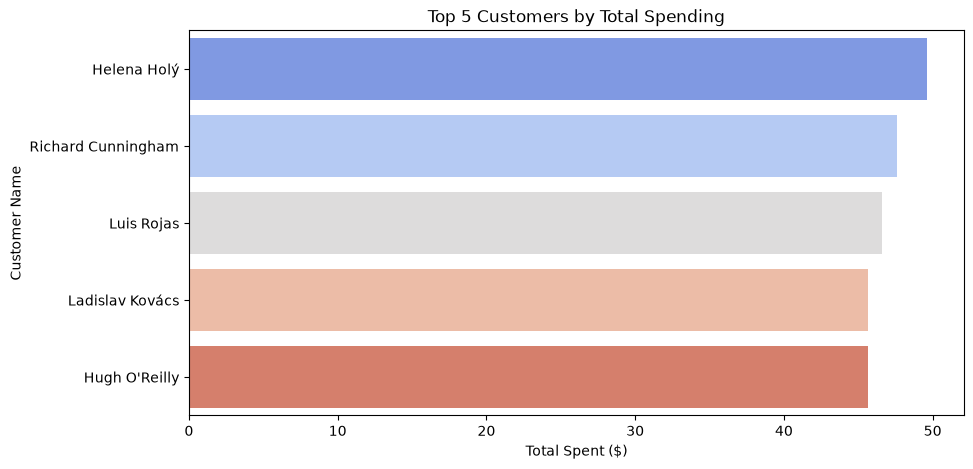

In [8]:
# Visualize top 5 customers by spending
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Spent', y='Customer_Name', data=df3, hue='Customer_Name', palette='coolwarm', legend=False)
plt.title('Top 5 Customers by Total Spending')
plt.xlabel('Total Spent ($)')
plt.ylabel('Customer Name')
plt.show()

In [9]:
# Question 4: What are the top 10 most popular music genres?
query = """
SELECT g.Name as Genre, COUNT(il.InvoiceLineId) as Total_Purchases
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
JOIN Genre g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY Total_Purchases DESC
LIMIT 10
"""
df4 = pd.read_sql(query, conn)
print(df4)

                Genre  Total_Purchases
0                Rock              835
1               Latin              386
2               Metal              264
3  Alternative & Punk              244
4                Jazz               80
5               Blues               61
6            TV Shows               47
7            R&B/Soul               41
8           Classical               41
9              Reggae               30


In [10]:
# Visualize top 10 genres
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Purchases', y='Genre', data=df4, hue='Genre', palette='Set2', legend=False)
plt.title('Top 10 Most Popular Music Genres')
plt.xlabel('Total Purchases')
plt.ylabel('Genre')
plt.show()z

SyntaxError: invalid syntax (305828725.py, line 7)

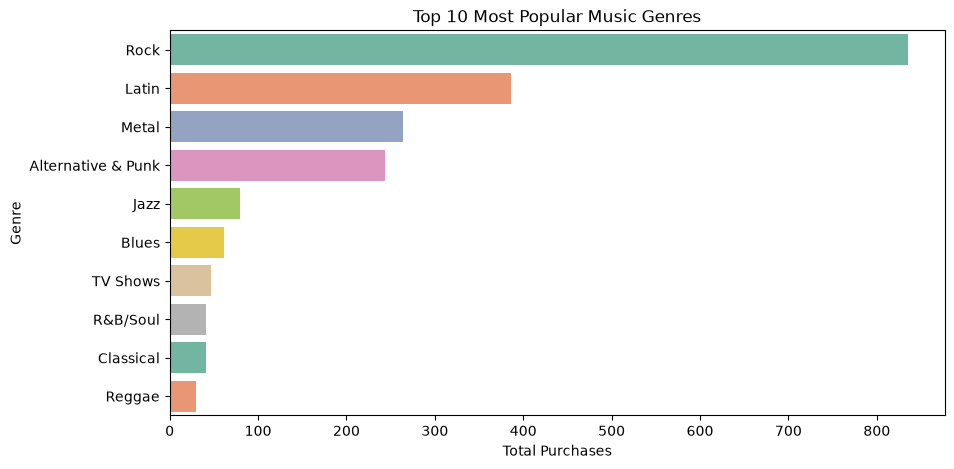

In [11]:
# Visualize top 10 genres
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Purchases', y='Genre', data=df4, hue='Genre', palette='Set2', legend=False)
plt.title('Top 10 Most Popular Music Genres')
plt.xlabel('Total Purchases')
plt.ylabel('Genre')
plt.show()

In [12]:
# Question 5: What are the top 10 best selling artists?
query = """
SELECT ar.Name as Artist, COUNT(il.InvoiceLineId) as Total_Sales
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
JOIN Album al ON t.AlbumId = al.AlbumId
JOIN Artist ar ON al.ArtistId = ar.ArtistId
GROUP BY ar.Name
ORDER BY Total_Sales DESC
LIMIT 10
"""
df5 = pd.read_sql(query, conn)
print(df5)

                    Artist  Total_Sales
0              Iron Maiden          140
1                       U2          107
2                Metallica           91
3             Led Zeppelin           87
4  Os Paralamas Do Sucesso           45
5              Deep Purple           44
6            Faith No More           42
7                     Lost           41
8             Eric Clapton           40
9                   R.E.M.           39


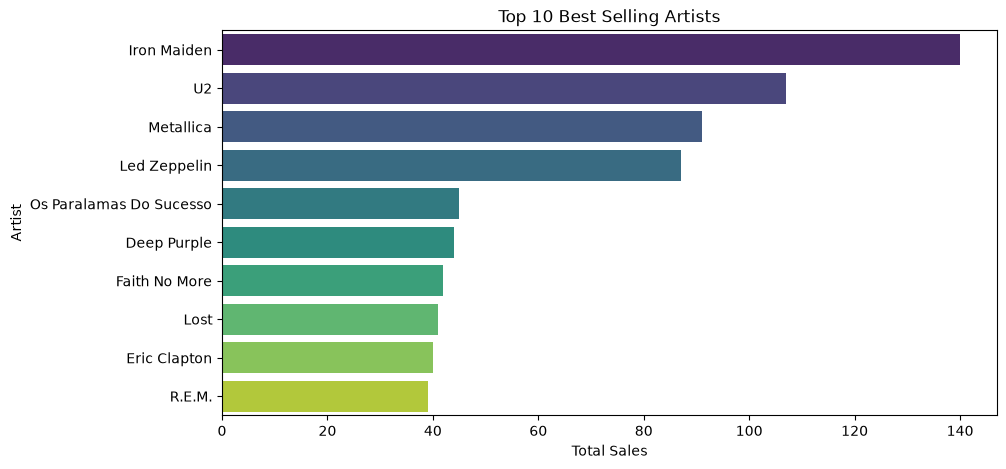

In [13]:
# Visualize top 10 best selling artists
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Sales', y='Artist', data=df5, hue='Artist', palette='viridis', legend=False)
plt.title('Top 10 Best Selling Artists')
plt.xlabel('Total Sales')
plt.ylabel('Artist')
plt.show()

In [14]:
# Key Findings Summary
print("""
KEY FINDINGS
============
1. USA has the most customers (13) and highest revenue ($523.06)
2. Helena Holý is the top spending customer at $49.62
3. Rock is the most popular genre with 835 purchases
4. Iron Maiden is the best selling artist with 140 sales
5. Canada is the second largest market after USA
""")


KEY FINDINGS
1. USA has the most customers (13) and highest revenue ($523.06)
2. Helena Holý is the top spending customer at $49.62
3. Rock is the most popular genre with 835 purchases
4. Iron Maiden is the best selling artist with 140 sales
5. Canada is the second largest market after USA

